In [13]:
# import requests
# import torch
# from PIL import Image
# from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation
#
#
# # load Mask2Former fine-tuned on ADE20k semantic segmentation
# processor = AutoImageProcessor.from_pretrained("facebook/mask2former-swin-base-ade-semantic")
# model = Mask2FormerForUniversalSegmentation.from_pretrained("facebook/mask2former-swin-base-ade-semantic")
#
# # url = "http://images.cocodataset.org/val2017/000000039769.jpg"
# # image = Image.open(requests.get(url, stream=True).raw)
# image = Image.open("./automated_underwater_area_estimation/data_preprocessed/IBF/out_images/GA 1_PB100636_rot00_aug00.jpg")
# inputs = processor(images=image, return_tensors="pt")
#
# with torch.no_grad():
#     outputs = model(**inputs)
#
# # model predicts class_queries_logits of shape `(batch_size, num_queries)`
# # and masks_queries_logits of shape `(batch_size, num_queries, height, width)`
# class_queries_logits = outputs.class_queries_logits
# masks_queries_logits = outputs.masks_queries_logits
#
# # you can pass them to processor for postprocessing
# predicted_semantic_map = processor.post_process_semantic_segmentation(outputs, target_sizes=[image.size[::-1]])[0]
# # we refer to the demo notebooks for visualization (see "Resources" section in the Mask2Former docs)


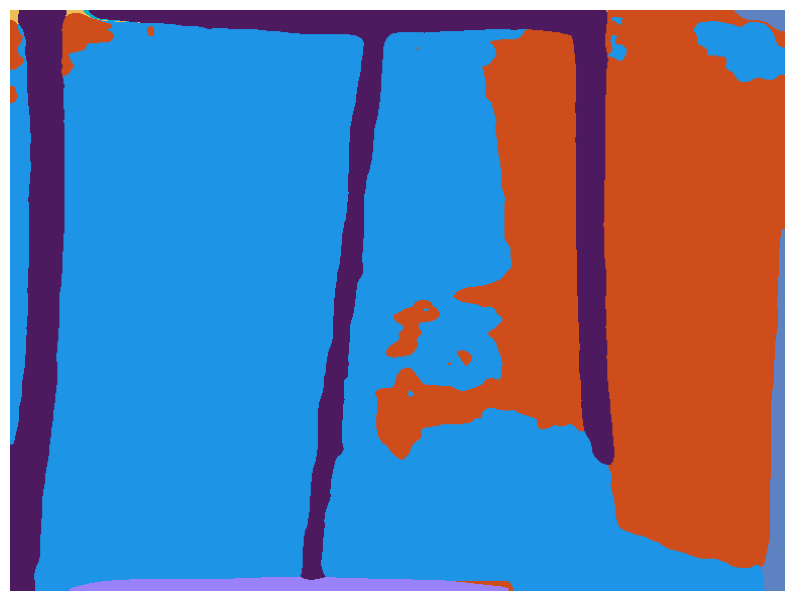

In [15]:
# import torch
# import numpy as np
# import matplotlib.pyplot as plt
# from PIL import Image
#
# # (Assume your code up to prediction is the same:)
# # processor = AutoImageProcessor.from_pretrained(...)
# # model = Mask2FormerForUniversalSegmentation.from_pretrained(...)
# # image loaded, inputs prepared, outputs computed
#
# # Post-process to semantic map at image resolution
#
#
# predicted_semantic_map = processor.post_process_semantic_segmentation(
#     outputs, target_sizes=[image.size[::-1]]
# )[0]  # shape (H, W), each value is a class index
#
# # Build a color palette (one color per class)
# num_classes = model.config.num_labels
# rng = np.random.default_rng(0)
# palette = rng.integers(0, 255, size=(num_classes, 3), dtype=np.uint8)
#
# # Convert predicted map to color image
# color_mask = palette[predicted_semantic_map.cpu().numpy()]  # (H, W, 3)
#
# # Create overlay image
# overlay = Image.fromarray(color_mask).convert("RGBA")
# alpha = 1
# overlay.putalpha(int(255 * alpha))
#
# base = image.convert("RGBA")
# blended = Image.alpha_composite(base, overlay)
#
# # Plot
# plt.figure(figsize=(10, 8))
# plt.imshow(blended)
# plt.axis("off")
# plt.show()


# Model

In [5]:
from pathlib import Path
from typing import List, Dict, Any, Tuple
import random
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image

from transformers import AutoImageProcessor, SegformerForSemanticSegmentation, TrainingArguments, Trainer
import torch.nn.functional as F
import evaluate

# ----------------------
# CONFIG
# ----------------------
base = "./automated_underwater_area_estimation/data_preprocessed/IBF/"
OUT_IMG_DIR = Path(base + "out_images")
OUT_MASK_DIR = Path(base + "out_masks")
SPLITS_DIR   = Path(base + "splits")   # will be created; txt files saved here
SPLITS_DIR.mkdir(exist_ok=True, parents=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp"}
# CHECKPOINT = "nvidia/segformer-b5-finetuned-ade-640-640"  # change to B4/B3 if VRAM is tight
CHECKPOINT = "nvidia/mit-b0"  # change to B4/B3 if VRAM is tight

VAL_RATIO   = 0.2
SEED        = 42
IGNORE_IDX  = 255
# If you want the processor to resize to a fixed train size, set this:
TARGET_SIZE: Tuple[int,int] | None = (1024, 768)  # (W,H) or None to let processor decide


def load_mask_pt(path: str) -> torch.Tensor:
    """Return torch.bool (H,W)."""
    data = torch.load(path, map_location="cpu")
    t = data["mask"] if isinstance(data, dict) and "mask" in data else data
    if not isinstance(t, torch.Tensor):
        raise ValueError(f"Unsupported mask in {path}")
    if t.ndim == 3 and t.shape[0] in (1,3):
        t = t.max(dim=0).values
    elif t.ndim == 3 and t.shape[2] == 1:
        t = t[..., 0]
    t = t > 0.5 if t.dtype.is_floating_point else t.bool()
    return t


def discover_pairs(img_dir: Path, mask_dir: Path) -> List[Tuple[Path, Path]]:
    pairs = []
    for p in img_dir.iterdir():
        if p.suffix.lower() not in IMAGE_EXTS:
            continue
        stem = p.stem  # e.g., foo_aug00
        m = mask_dir / f"{stem}.pt"
        if m.exists():
            pairs.append((p, m))
    return sorted(pairs, key=lambda x: x[0].name)


def stratified_split_on_foreground(pairs: List[Tuple[Path,Path]], val_ratio=0.2, seed=42):
    """
    Simple stratification: split by whether mask has any foreground (True).
    """
    rng = random.Random(seed)
    pos, neg = [], []
    for img_p, mask_p in pairs:
        mask = load_mask_pt(str(mask_p))
        (pos if mask.any().item() else neg).append((img_p, mask_p))

    def split_bucket(bucket):
        rng.shuffle(bucket)
        n_val = max(1, int(round(len(bucket)*val_ratio))) if len(bucket) > 0 else 0
        return bucket[n_val:], bucket[:n_val]

    train_pos, val_pos = split_bucket(pos)
    train_neg, val_neg = split_bucket(neg)

    train = train_pos + train_neg
    val   = val_pos + val_neg
    rng.shuffle(train)
    rng.shuffle(val)
    return train, val


def save_split(stems: List[str], path: Path):
    path.write_text("\n".join(stems) + "\n", encoding="utf-8")


class QuadPreAugDataset(Dataset):
    """
    Dataset that reads pre-augmented files from disk (no runtime Albumentations).
    Uses HF processor for normalization and (optional) resize.
    """
    def __init__(self, items: List[Tuple[Path,Path]], processor, target_size: Tuple[int,int] | None, train: bool):
        self.items = items
        self.processor = processor
        self.target_size = target_size
        self.train = train

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx) -> Dict[str, Any]:
        img_path, mask_path = self.items[idx]
        img = Image.open(img_path).convert("RGB")
        mask = load_mask_pt(str(mask_path)).to(torch.int64)  # (H,W) 0/1

        # Prepare inputs via processor; if target_size is set, resize here
        if self.target_size is not None:
            w, h = self.target_size
            encoded = self.processor(
                images=img,
                segmentation_maps=mask.numpy(),
                return_tensors="pt",
                size={"height": h, "width": w},
            )
        else:
            encoded = self.processor(images=img, segmentation_maps=mask.numpy(), return_tensors="pt")

        item = {k: v.squeeze(0) for k, v in encoded.items()}
        return item


In [6]:
# Discover paired samples
pairs = discover_pairs(OUT_IMG_DIR, OUT_MASK_DIR)
print(f"Found {len(pairs)} samples in {OUT_IMG_DIR} / {OUT_MASK_DIR}")

# Programmatic (stratified) split
train_pairs, val_pairs = stratified_split_on_foreground(pairs, val_ratio=VAL_RATIO, seed=SEED)
print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)}")

# Save split files (optional, for bookkeeping)
train_stems = [p[0].stem for p in train_pairs]
val_stems   = [p[0].stem for p in val_pairs]
save_split(train_stems, SPLITS_DIR / "train.txt")
save_split(val_stems,   SPLITS_DIR / "val.txt")

# Build processor & datasets
processor = AutoImageProcessor.from_pretrained(CHECKPOINT, reduce_labels=False, use_fast=True)
train_ds  = QuadPreAugDataset(train_pairs, processor, TARGET_SIZE, train=True)
val_ds    = QuadPreAugDataset(val_pairs,   processor, TARGET_SIZE, train=False)


Found 2198 samples in automated_underwater_area_estimation\data_preprocessed\IBF\out_images / automated_underwater_area_estimation\data_preprocessed\IBF\out_masks
Train: 1758 | Val: 440


In [9]:
id2label = {0: "background", 1: "quadrant"}
label2id = {v:k for k,v in id2label.items()}

model = SegformerForSemanticSegmentation.from_pretrained(
    CHECKPOINT,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)
model.config.semantic_loss_ignore_index = IGNORE_IDX
model.config.dropout = 0.1
model.config.classifier_dropout = 0.1

# --- Dice + CE (foreground-aware) ---
def soft_dice_loss(logits, labels, eps=1e-6):
    # logits: (B,2,H,W), labels: (B,H,W)
    probs = logits.softmax(dim=1)[:, 1]  # class=1
    target = (labels == 1).float()
    num = 2 * (probs * target).sum(dim=(1,2))
    den = (probs.pow(2) + target.pow(2)).sum(dim=(1,2)) + eps
    return (1 - (num + eps) / (den + eps)).mean()

class DiceCETrainer(Trainer):
    """
    Custom Trainer that uses weighted CE + Dice loss.
    """
    def __init__(self, *args, ce_weight=(0.3, 0.7), dice_weight=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        # Store as regular attributes - move to device when computing loss
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # (B, num_classes, H, W)

        # Upsample logits to match label size
        upsampled_logits = F.interpolate(
            logits,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        # Move ce_weight to the same device as logits
        device = upsampled_logits.device
        ce_class_weight = torch.tensor(self.ce_weight, dtype=torch.float32, device=device)

        # Cross-entropy loss with class weights
        ce_loss = F.cross_entropy(
            upsampled_logits,
            labels,
            weight=ce_class_weight,
            reduction="mean"
        )

        # Dice loss
        dice_loss = soft_dice_loss(upsampled_logits, labels)

        total_loss = ce_loss + self.dice_weight * dice_loss

        return (total_loss, outputs) if return_outputs else total_loss
# --- Metrics: mIoU / mF1 ---
metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    logits_t = torch.from_numpy(logits).float()
    # Upsample to label size in case processor resized differently
    preds = torch.nn.functional.interpolate(
        logits_t, size=labels.shape[-2:], mode="bilinear", align_corners=False
    ).argmax(1).cpu().numpy().astype(np.int64)

    res = metric.compute(
        predictions=list(preds),
        references=list(labels.astype(np.int64)),
        num_labels=2,
        ignore_index=IGNORE_IDX,
        reduce_labels=False,
    )
    return {
        "miou": res["mean_iou"],
        "mf1": res["mean_f1"],
        "iou_bg": res["per_category_iou"][0],
        "iou_quad": res["per_category_iou"][1],
        "f1_bg": res["per_category_f1"][0],
        "f1_quad": res["per_category_f1"][1],
    }


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b0 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Exception ignored in: <function tqdm.__del__ at 0x000001CAEF79C180>
Traceback (most recent call last):
  File "C:\Users\Chekm\Jupiter\automated-underwater-area-estimat

In [10]:
args = TrainingArguments(
    output_dir="segformer_quad_preaug",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,  # effective batch 8
    learning_rate=6e-5,
    num_train_epochs=10,           # pre-aug data typically needs fewer epochs; tune as needed
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    save_strategy="epoch",
    eval_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="miou",
    seed=SEED,
    bf16=torch.cuda.is_available(),  # or fp16=True
)

trainer = DiceCETrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=processor,   # satisfies Trainer API
    compute_metrics=compute_metrics,
    ce_weight=(0.3, 0.7),  # ↑ weight for quadrant if it’s small
    dice_weight=1.0,
)

trainer.train()


C:\Users\Chekm\AppData\Local\Temp\ipykernel_25976\4001999942.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `DiceCETrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

# Inference

In [2]:
import torch
import numpy as np
from PIL import Image

def segment_and_overlay(
    image_path: str,
    model,
    processor,
    device: str | None = None,
    overlay_color=(255, 0, 0),  # RGB for the quadrant
    alpha: float = 0.45,        # overlay transparency
    threshold: float | None = None,  # None = argmax; or set a prob threshold for class 1
):
    """
    Run segmentation and overlay the quadrant mask on the original image.

    Returns:
        overlay_pil: PIL.Image with the mask overlaid
        pred_mask:   np.ndarray (H,W) uint8 {0,1}
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # 1) Load image (keep original size for display)
    img_pil = Image.open(image_path).convert("RGB")
    orig_w, orig_h = img_pil.size

    # 2) Prepare inputs (no resizing so we preserve original size)
    inputs = processor(images=img_pil, return_tensors="pt", do_resize=False)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 3) Forward pass
    model = model.to(device).eval()
    with torch.no_grad():
        out = model(**inputs)
        logits = out.logits  # (1, num_classes, h, w)

    # 4) Upsample logits to original image size and get predictions
    logits_up = torch.nn.functional.interpolate(
        logits, size=(orig_h, orig_w), mode="bilinear", align_corners=False
    )

    if threshold is None:
        # argmax over classes -> labels {0,1}
        pred = logits_up.argmax(1)[0].detach().cpu().numpy().astype(np.uint8)
    else:
        # probability for class 1, then threshold
        probs1 = torch.softmax(logits_up, dim=1)[:, 1, :, :]  # (1,H,W)
        pred = (probs1[0] > float(threshold)).detach().cpu().numpy().astype(np.uint8)

    # 5) Build overlay
    base = np.array(img_pil).astype(np.float32)  # (H,W,3)
    mask = pred.astype(bool)

    overlay = np.zeros_like(base)
    overlay[..., 0] = overlay_color[0]
    overlay[..., 1] = overlay_color[1]
    overlay[..., 2] = overlay_color[2]

    # alpha blend only where mask==1
    out_img = base.copy()
    out_img[mask] = (alpha * overlay[mask] + (1 - alpha) * base[mask])

    overlay_pil = Image.fromarray(np.clip(out_img, 0, 255).astype(np.uint8))
    return overlay_pil, pred  # PIL image, and raw binary mask (H,W) {0,1}


In [8]:
final_dir = "segformer_best"
from transformers import SegformerForSemanticSegmentation, AutoImageProcessor

proc = AutoImageProcessor.from_pretrained(final_dir)
best_model = SegformerForSemanticSegmentation.from_pretrained(final_dir).eval()

overlay_img, mask = segment_and_overlay(
    "./automated_underwater_area_estimation/data_preprocessed/IBF/out_images/GA 1_PB100645_rot-15_aug00.jpg",
    model=best_model,
    processor=proc,
    overlay_color=(255, 0, 0),
    alpha=0.45,
    threshold=None,  # or e.g. 0.4 to force a probability cutoff for class 1
)

# Show or save
overlay_img.show()  # in notebooks, this displays inline
# overlay_img.save("overlay_result.jpg")
# 'mask' is a binary numpy array you can save if needed:
# Image.fromarray((mask * 255).astype(np.uint8)).save("mask.png")
